# Implementação de uma Rede Direta MLP com Aprendizado Supervisionado

**Disciplina:** Inteligência Computacional / Machine Learning — CESUPA

**Professora:** Polyana Santos Fonseca Nascimento

**Integrantes:** Rafael Batista Ferreira e Paulo Ricardo da Rocha Cunha

**Dataset:** Air Quality UCI (UCI Machine Learning Repository)


## 1. Escolha e validação do Dataset

**Dataset:** [Air Quality Data Set — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/360/air+quality)

**Tipo de problema:** Regressão.

**Descrição:** o dataset contém medições horárias de um equipamento multissensor de baixo custo (array de 5 sensores de óxido de metal) instalado em uma área urbana poluída na Itália, entre março de 2004 e abril de 2005, junto com as concentrações de referência medidas por um analisador certificado.

**Variável-alvo:** `C6H6(GT)` — concentração de benzeno de referência, em µg/m³ (medida pelo analisador certificado, não pelo sensor de baixo custo). Trata-se de um problema real de calibração de sensores: prever a leitura do equipamento de referência (caro) a partir das leituras dos sensores de baixo custo e de variáveis ambientais.

**Número de instâncias (antes da limpeza):** 9.357 (excluindo linhas totalmente vazias no fim do arquivo).

**Número de atributos (antes da limpeza):** 15 (incluindo Data e Hora), sendo 12 atributos numéricos além da variável-alvo.

**Natureza e faixa de valores da variável-alvo:** variável contínua, concentração de benzeno em µg/m³, variando de aproximadamente 0 a 63,7 µg/m³ nas leituras válidas (valores ausentes são codificados como -200 no dataset original e serão tratados na etapa de pré-processamento).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from scipy.stats import loguniform

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 2. Pré-processamento e Análise dos Dados

### 2.1. Carregamento e limpeza inicial

O arquivo usa `;` como separador de colunas e `,` como separador decimal (padrão europeu). As duas últimas colunas (`Unnamed: 15`, `Unnamed: 16`) são completamente vazias (artefato da exportação do CSV original) e são descartadas, assim como as linhas totalmente vazias ao final do arquivo.

Os valores ausentes no dataset original são codificados como **-200**, e não como `NaN`. Isso precisa ser tratado explicitamente.


In [2]:
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
print('Shape bruto:', df.shape)
df.head()


Shape bruto: (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [3]:
# Remove colunas totalmente vazias e linhas totalmente vazias
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
df = df.dropna(how='all', subset=['Date'])
print('Shape apos remover linhas/colunas vazias:', df.shape)

# Contagem de valores ausentes (-200) por coluna
missing_counts = (df.iloc[:, 2:] == -200).sum().sort_values(ascending=False)
print('\nValores ausentes (-200) por coluna:')
print(missing_counts)


Shape apos remover linhas/colunas vazias: (9357, 15)

Valores ausentes (-200) por coluna:
NMHC(GT)         8443
CO(GT)           1683
NO2(GT)          1642
NOx(GT)          1639
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
PT08.S3(NOx)      366
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


### 2.2. Tratamento de valores ausentes

- `NMHC(GT)` tem ~90% de valores ausentes (o sensor de referência para hidrocarbonetos não-metânicos falhou na maior parte do período). Como não é viável imputar de forma confiável uma coluna com 90% de dados faltantes, **a coluna é descartada**.
- A variável-alvo `C6H6(GT)` tem 366 valores ausentes, que correspondem a instantes em que **todo o equipamento sensor** ficou fora do ar (as mesmas 366 linhas têm -200 em todos os sensores `PT08.*`). Como não é possível treinar/avaliar supervisionadamente sem o rótulo, **essas linhas são descartadas**.
- Após remover essas linhas, os sensores `PT08.*`, `T`, `RH` e `AH` ficam sem valores ausentes (eram os mesmos instantes de falha do equipamento).
- `CO(GT)`, `NOx(GT)` e `NO2(GT)` são leituras do **analisador de referência** (não do equipamento de baixo custo) e ainda apresentam valores ausentes independentes (o analisador de referência falhou em outros instantes). Esses são **imputados pela mediana** da própria coluna, por ser uma medida robusta a outliers e por essas variáveis não serem extremamente enviesadas.


In [4]:
df = df.drop(columns=['NMHC(GT)'])
df = df[df['C6H6(GT)'] != -200].copy()
print('Shape apos remover linhas com alvo ausente:', df.shape)

for c in ['CO(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)',
          'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']:
    n_missing = (df[c] == -200).sum()
    if n_missing:
        print(f'{c}: {n_missing} valores -200 substituidos pela mediana')
        df[c] = df[c].replace(-200, np.nan)
        df[c] = df[c].fillna(df[c].median())

print('\nValores ausentes restantes:', (df.iloc[:, 2:] == -200).sum().sum())


Shape apos remover linhas com alvo ausente: (8991, 14)
CO(GT): 1647 valores -200 substituidos pela mediana
NOx(GT): 1595 valores -200 substituidos pela mediana
NO2(GT): 1598 valores -200 substituidos pela mediana

Valores ausentes restantes: 0


### 2.3. Engenharia de atributos a partir de Data/Hora

Poluentes atmosféricos têm forte padrão sazonal e diário (tráfego, temperatura, etc.). As colunas `Date` e `Time` são combinadas e decompostas em `hour`, `month` e `dayofweek`, que carregam essa informação de forma numérica utilizável pelo modelo; as colunas textuais originais são descartadas.


In [5]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df = df.sort_values('DateTime')  # garante ordem cronologica (usada no holdout temporal)
df['hour'] = df['DateTime'].dt.hour
df['month'] = df['DateTime'].dt.month
df['dayofweek'] = df['DateTime'].dt.dayofweek
datetimes = df['DateTime'].reset_index(drop=True)  # guardado para os graficos da Secao 10
df = df.drop(columns=['Date', 'Time', 'DateTime'])
df = df.reset_index(drop=True)
df.head()


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,hour,month,dayofweek
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18,3,2
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19,3,2
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20,3,2
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21,3,2
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22,3,2


### 2.4. Análise da variável-alvo (distribuição, escala, dispersão, outliers)


count    8991.000000
mean       10.083105
std         7.449820
min         0.100000
25%         4.400000
50%         8.200000
75%        14.000000
max        63.700000
Name: C6H6(GT), dtype: float64


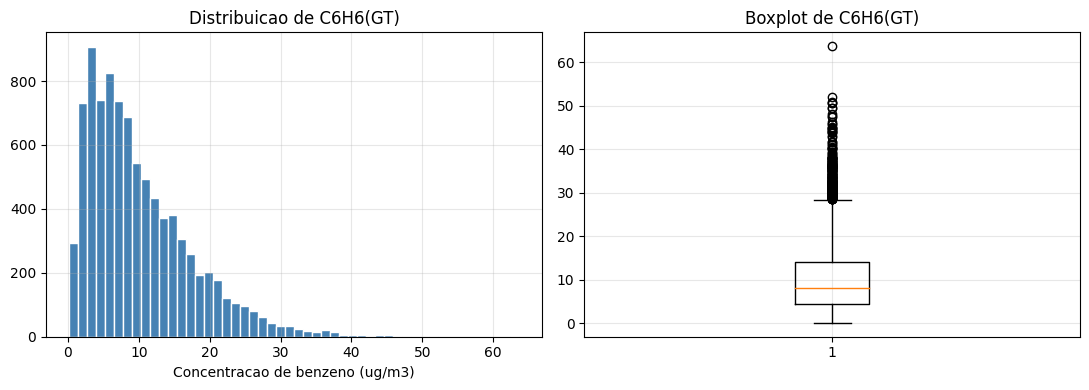

In [6]:
print(df['C6H6(GT)'].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['C6H6(GT)'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuicao de C6H6(GT)')
axes[0].set_xlabel('Concentracao de benzeno (ug/m3)')
axes[1].boxplot(df['C6H6(GT)'], vert=True)
axes[1].set_title('Boxplot de C6H6(GT)')
plt.tight_layout()
plt.show()


A variável-alvo é assimétrica à direita (cauda longa de concentrações altas, típica de poluentes atmosféricos) e possui alguns valores elevados que são picos reais de poluição (tráfego intenso, condições climáticas), não erros de medição — portanto **não** são tratados como outliers a remover. Como o objetivo é prever o valor real, **não aplicamos transformação (ex.: log) à variável-alvo** nesta versão, para manter a interpretação direta das métricas em µg/m³; o modelo (MLP com StandardScaler nas features) é capaz de lidar com essa assimetria moderada. Isso é revisitado na análise crítica final.

### 2.5. Escalas dos atributos

Os atributos têm escalas muito diferentes entre si (ex.: `PT08.S1(CO)` na casa de milhares, `AH` na casa de décimos). Isso é tratado com `StandardScaler`, aplicado **dentro de um `Pipeline`** para que a padronização seja ajustada (fit) apenas nos dados de treino em cada fold da validação cruzada, evitando vazamento de dados (data leakage).


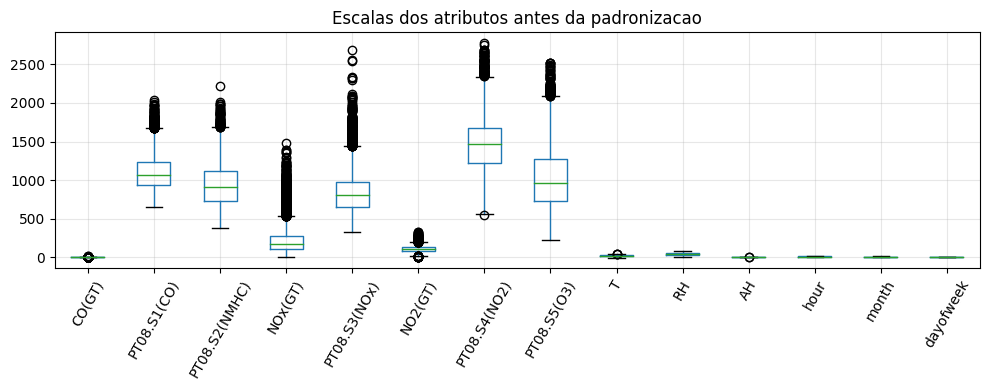

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
df.drop(columns=['C6H6(GT)']).boxplot(rot=60, ax=ax)
ax.set_title('Escalas dos atributos antes da padronizacao')
plt.tight_layout()
plt.show()


### 2.6. Separação do conjunto de teste (holdout)

Reservamos 20% dos dados como conjunto de teste (holdout), que **não participa** da validação cruzada nem da busca de hiperparâmetros — é usado apenas na avaliação final do modelo já escolhido.

Como os dados são uma **série temporal** (medições horárias de março/2004 a fevereiro/2005), a separação **não é aleatória**: o holdout é formado pelos **20% de registros mais recentes** (últimos na ordem cronológica), e o treino pelos 80% mais antigos (`shuffle=False`). Assim o modelo é avaliado como seria usado na prática — prevendo o futuro a partir do passado — e evitamos que observações de horas vizinhas às do teste (muito correlacionadas) estejam no treino, o que tornaria a avaliação otimista.

In [8]:
y = df.pop('C6H6(GT)').values
X = df.values
feature_names = df.columns.tolist()
print('Atributos utilizados:', feature_names)
print('X shape:', X.shape, '| y shape:', y.shape)

# Holdout temporal: os 20% mais recentes vao para teste (sem embaralhar)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print('Treino (para CV/busca de hiperparametros):', X_train.shape)
print('Teste (holdout, reservado):', X_test.shape)


Atributos utilizados: ['CO(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour', 'month', 'dayofweek']
X shape: (8991, 14) | y shape: (8991,)
Treino (para CV/busca de hiperparametros): (7192, 14)
Teste (holdout, reservado): (1799, 14)


### 2.7. Métricas escolhidas

Para este problema de regressão, usamos:
- **RMSE** (Root Mean Squared Error) — métrica principal, na mesma unidade da variável-alvo (µg/m³), penaliza mais erros grandes; usada como critério de otimização nas buscas de hiperparâmetros.
- **MAE** (Mean Absolute Error) — mais interpretável e robusta a outliers, complementa o RMSE.
- **R²** — proporção da variância explicada, para dar uma noção relativa de qualidade do ajuste.


## 3. Construção da MLP

Usamos `sklearn.neural_network.MLPRegressor` (rede neural feed-forward totalmente conectada, treinada por backpropagation), dentro de um `Pipeline` com `StandardScaler`. O modelo usa `early_stopping=True`, separando internamente uma fração de validação do próprio conjunto de treino de cada fold para decidir quando parar (paciência = `n_iter_no_change`), o que também ajuda a controlar overfitting.

**Validação cruzada temporal:** pelo mesmo motivo do holdout (Seção 2.6), a validação cruzada usa `TimeSeriesSplit` com 3 folds em vez de `KFold` embaralhado. O conjunto de treino é dividido em 4 blocos cronológicos consecutivos; no fold *k*, o modelo é treinado nos *k* primeiros blocos e validado no bloco seguinte. Assim, a validação nunca usa dados anteriores ao treino, e o RMSE de validação cruzada estima o erro em um cenário de previsão real (passado → futuro). Como consequência, os primeiros folds treinam com menos dados e validam em estações do ano ainda não vistas, o que tende a produzir RMSE de validação cruzada maior e mais variável do que com `KFold` embaralhado.


In [9]:
def make_pipeline(random_state=RANDOM_STATE):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=random_state,
        ))
    ])

# Validacao cruzada temporal: cada fold treina no passado e valida no periodo seguinte
cv = TimeSeriesSplit(n_splits=3)
SCORING = 'neg_root_mean_squared_error'

# sanity check: um treino rapido com hiperparametros default
pipe = make_pipeline()
t0 = time.time()
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(f'RMSE (config default, so para checar que o pipeline funciona): '
      f'{root_mean_squared_error(y_test, pred):.3f}  ({time.time()-t0:.1f}s)')


RMSE (config default, so para checar que o pipeline funciona): 0.537  (3.8s)


## 4. Baseline de ajuste de hiperparâmetros — Random Search

**Espaço de busca** (coerente com o problema — rede pequena/média para ~13 atributos e ~7.200 instâncias de treino):

| Hiperparâmetro | Faixa / opções |
|---|---|
| número de camadas ocultas | 1, 2 ou 3 |
| número de neurônios por camada | 16, 32, 64 ou 128 |
| função de ativação | ReLU, tanh |
| learning rate inicial | log-uniforme entre 1e-4 e 5e-2 |
| batch size | 32, 64 ou 128 |
| otimizador (solver) | Adam, SGD |
| paciência do Early Stopping | 5, 10 ou 15 épocas sem melhora |

O número de camadas e o número de neurônios são amostrados separadamente e combinados em `hidden_layer_sizes` (mesma largura em todas as camadas, por simplicidade).

Validação cruzada: `TimeSeriesSplit` com 3 folds (sobre o conjunto de treino apenas), métrica principal RMSE. Orçamento: **25 configurações**.


In [10]:
from sklearn.base import BaseEstimator, RegressorMixin

class MLPRegressorFlexible(BaseEstimator, RegressorMixin):
    """Wrapper que expande (n_hidden_layers, n_neurons) em hidden_layer_sizes,
    para que Random/TPE possam buscar sobre os hiperparametros pedidos no enunciado
    de forma independente."""
    def __init__(self, n_hidden_layers=1, n_neurons=64, activation='relu', solver='adam',
                 learning_rate_init=0.001, batch_size=64, n_iter_no_change=10,
                 max_iter=200, random_state=RANDOM_STATE):
        self.n_hidden_layers = n_hidden_layers
        self.n_neurons = n_neurons
        self.activation = activation
        self.solver = solver
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.n_iter_no_change = n_iter_no_change
        self.max_iter = max_iter
        self.random_state = random_state

    def _build(self):
        hidden_layer_sizes = tuple([self.n_neurons] * self.n_hidden_layers)
        return MLPRegressor(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=self.activation,
            solver=self.solver,
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size,
            n_iter_no_change=self.n_iter_no_change,
            max_iter=self.max_iter,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=self.random_state,
        )

    def fit(self, X, y):
        self.model_ = self._build()
        self.model_.fit(X, y)
        self.n_iter_ = self.model_.n_iter_
        return self

    def predict(self, X):
        return self.model_.predict(X)


def make_flex_pipeline(random_state=RANDOM_STATE):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressorFlexible(random_state=random_state)),
    ])

param_distributions = {
    'mlp__n_hidden_layers': [1, 2, 3],
    'mlp__n_neurons': [16, 32, 64, 128],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__solver': ['adam', 'sgd'],
    'mlp__learning_rate_init': loguniform(1e-4, 5e-2),
    'mlp__batch_size': [32, 64, 128],
    'mlp__n_iter_no_change': [5, 10, 15],
}

t0 = time.time()
random_search = RandomizedSearchCV(
    make_flex_pipeline(), param_distributions, n_iter=25, cv=cv,
    scoring=SCORING, random_state=RANDOM_STATE, n_jobs=1, refit=True, verbose=0,
)
random_search.fit(X_train, y_train)
rs_time = time.time() - t0
print(f'Random Search concluido em {rs_time:.1f}s')
print('Melhor RMSE (CV):', -random_search.best_score_)
print('Melhores hiperparametros:', random_search.best_params_)


Random Search concluido em 176.4s
Melhor RMSE (CV): 0.2874604132795194
Melhores hiperparametros: {'mlp__activation': 'relu', 'mlp__batch_size': 32, 'mlp__learning_rate_init': 0.012141307774357374, 'mlp__n_hidden_layers': 3, 'mlp__n_iter_no_change': 15, 'mlp__n_neurons': 64, 'mlp__solver': 'adam'}


In [11]:
rs_results = pd.DataFrame(random_search.cv_results_)
rs_results['rmse'] = -rs_results['mean_test_score']
rs_table = rs_results.sort_values('rmse').head(10)[
    ['rank_test_score', 'rmse', 'std_test_score'] +
    [c for c in rs_results.columns if c.startswith('param_mlp__')]
].reset_index(drop=True)
rs_table.columns = [c.replace('param_mlp__', '') for c in rs_table.columns]
rs_table


,rank_test_score,rmse,std_test_score,activation,batch_size,learning_rate_init,n_hidden_layers,n_iter_no_change,n_neurons,solver
0,1,0.287460,0.059834,relu,32,0.012141,3,15,64,adam
1,2,0.569623,0.285634,relu,32,0.00887,3,15,32,adam
2,3,0.592817,0.388662,relu,64,0.036393,2,10,32,adam
3,4,0.678686,0.168050,relu,128,0.02616,1,5,128,sgd
4,5,0.696183,0.418694,tanh,64,0.002533,2,10,16,adam
5,6,0.719429,0.172180,tanh,128,0.013573,3,5,32,adam
6,7,0.765111,0.118182,tanh,64,0.015174,1,5,32,sgd
7,8,0.783243,0.557674,relu,32,0.008281,2,10,128,adam
8,9,0.795134,0.114414,tanh,32,0.00042,3,15,128,adam
9,10,0.873787,0.239682,relu,128,0.006385,1,15,128,sgd


Tabela acima: as 10 melhores das 25 configurações testadas pelo Random Search, ordenadas por RMSE médio (validação cruzada, menor é melhor).

## 5. Busca adaptativa de hiperparâmetros — TPE (Optuna)

Mesmo espaço de busca, mesmos intervalos/opções, mesma estratégia de validação cruzada (`TimeSeriesSplit` com 3 folds), mesma métrica (RMSE) e mesmo orçamento (25 trials), agora usando o algoritmo **TPE (Tree-structured Parzen Estimator)**, que constrói um modelo probabilístico de quais regiões do espaço de busca tendem a gerar bons resultados e amostra pontos mais promissores ao longo da busca (diferente do Random Search, que amostra uniformemente e não aprende com os resultados anteriores).


In [12]:
def make_objective(X_tr, y_tr, cv_):
    def objective(trial):
        n_hidden_layers = trial.suggest_categorical('n_hidden_layers', [1, 2, 3])
        n_neurons = trial.suggest_categorical('n_neurons', [16, 32, 64, 128])
        activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
        solver = trial.suggest_categorical('solver', ['adam', 'sgd'])
        learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 5e-2, log=True)
        batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
        n_iter_no_change = trial.suggest_categorical('n_iter_no_change', [5, 10, 15])

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPRegressorFlexible(
                n_hidden_layers=n_hidden_layers, n_neurons=n_neurons, activation=activation,
                solver=solver, learning_rate_init=learning_rate_init, batch_size=batch_size,
                n_iter_no_change=n_iter_no_change, random_state=RANDOM_STATE,
            )),
        ])
        scores = cross_val_score(pipe, X_tr, y_tr, cv=cv_, scoring=SCORING, n_jobs=1)
        return -scores.mean()
    return objective

t0 = time.time()
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(make_objective(X_train, y_train, cv), n_trials=25, show_progress_bar=False, catch=(ValueError,))
tpe_time = time.time() - t0
print(f'TPE (Optuna) concluido em {tpe_time:.1f}s')
print('Melhor RMSE (CV):', study.best_value)
print('Melhores hiperparametros:', study.best_params)

[W 2026-09-30 21:13:20,266] Trial 12 failed with parameters: {'n_hidden_layers': 1, 'n_neurons': 128, 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.03841218297831331, 'batch_size': 32, 'n_iter_no_change': 15} because of the following error: ValueError('\nAll the 3 fits failed.\nIt is very likely that your model is misconfigured.\nYou can try to debug the error by setting error_score=\'raise\'.\n\nBelow are more details about the failures:\n--------------------------------------------------------------------------------\n3 fits failed with the following error:\nTraceback (most recent call last):\n  File "C:\\Users\\paulo\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\sklearn\\model_selection\\_validation.py", line 895, in _fit_and_score\n    estimator.fit(X_train, y_train, **fit_params)\n  File "C:\\Users\\paulo\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra

[W 2026-09-30 21:13:20,268] Trial 12 failed with value None.


[W 2026-09-30 21:13:32,119] Trial 19 failed with parameters: {'n_hidden_layers': 1, 'n_neurons': 64, 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.024657231597562387, 'batch_size': 32, 'n_iter_no_change': 10} because of the following error: The value nan is not acceptable.


[W 2026-09-30 21:13:32,121] Trial 19 failed with value nan.


TPE (Optuna) concluido em 136.8s
Melhor RMSE (CV): 0.27778297533493096
Melhores hiperparametros: {'n_hidden_layers': 1, 'n_neurons': 16, 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.015667246197124923, 'batch_size': 32, 'n_iter_no_change': 10}


In [13]:
tpe_trials = study.trials_dataframe()
tpe_trials = tpe_trials.rename(columns={'value': 'rmse'})
cols = ['number', 'rmse'] + [c for c in tpe_trials.columns if c.startswith('params_')]
tpe_table = tpe_trials[cols].sort_values('rmse').head(10).reset_index(drop=True)
tpe_table.columns = [c.replace('params_', '') for c in tpe_table.columns]
tpe_table


,number,rmse,activation,batch_size,learning_rate_init,n_hidden_layers,n_iter_no_change,n_neurons,solver
0,20,0.277783,relu,32,0.015667,1,10,16,sgd
1,0,0.304608,relu,32,0.041472,2,15,16,adam
2,18,0.314652,relu,32,0.023592,1,10,16,sgd
3,11,0.325736,relu,32,0.031179,2,15,16,adam
4,10,0.327057,relu,32,0.028860,2,15,16,adam
5,21,0.345814,relu,32,0.009175,3,10,32,sgd
6,22,0.383433,relu,32,0.009499,1,10,16,sgd
7,15,0.459518,relu,32,0.006692,1,15,16,adam
8,13,0.481288,relu,128,0.043957,1,15,16,adam
9,24,0.612111,relu,32,0.002207,1,10,32,sgd


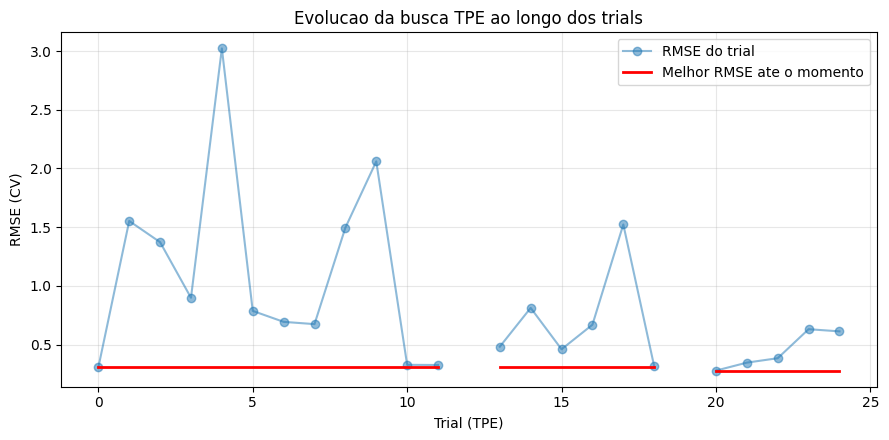

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
trials_sorted = tpe_trials.sort_values('number')
running_best = trials_sorted['rmse'].cummin()
ax.plot(trials_sorted['number'], trials_sorted['rmse'], 'o-', alpha=0.5, label='RMSE do trial')
ax.plot(trials_sorted['number'], running_best, 'r-', linewidth=2, label='Melhor RMSE ate o momento')
ax.set_xlabel('Trial (TPE)')
ax.set_ylabel('RMSE (CV)')
ax.set_title('Evolucao da busca TPE ao longo dos trials')
ax.legend()
plt.tight_layout()
plt.show()


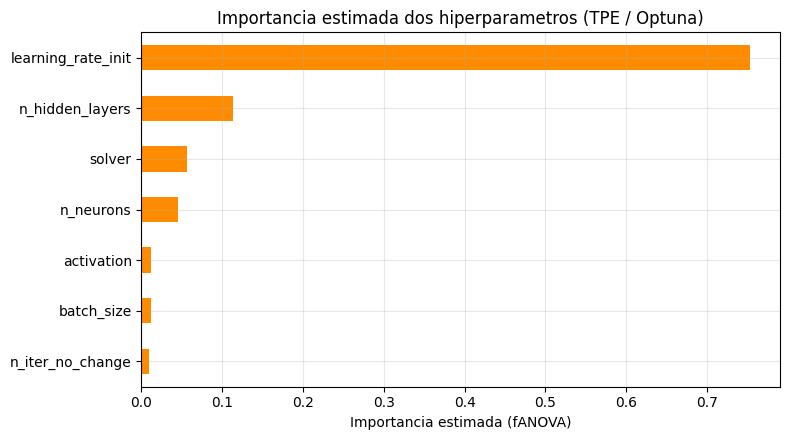

learning_rate_init    0.752764
n_hidden_layers       0.112918
solver                0.055930
n_neurons             0.045333
activation            0.011885
batch_size            0.011641
n_iter_no_change      0.009530
dtype: float64


In [15]:
importances = optuna.importance.get_param_importances(study)
imp_series = pd.Series(importances).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
imp_series.plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Importancia estimada (fANOVA)')
ax.set_title('Importancia estimada dos hiperparametros (TPE / Optuna)')
plt.tight_layout()
plt.show()
print(imp_series.sort_values(ascending=False))


## 6. Comparação entre Random Search e TPE


In [16]:
comparison = pd.DataFrame({
    'estrategia': ['Random Search', 'TPE (Optuna)'],
    'orcamento_trials': [25, 25],
    'melhor_rmse_cv': [-random_search.best_score_, study.best_value],
    'tempo_segundos': [rs_time, tpe_time],
})
comparison


,estrategia,orcamento_trials,melhor_rmse_cv,tempo_segundos
0,Random Search,25,0.287460,176.402256
1,TPE (Optuna),25,0.277783,136.848104


**Resultado desta execução:** o Random Search encontrou RMSE de validação cruzada = **0,2875**; o TPE encontrou RMSE = **0,2778**, cerca de 3% menor, e terminou mais rápido (ver coluna `tempo_segundos` da tabela acima; os tempos exatos variam de uma execução para outra). Com o mesmo orçamento de 25 configurações, o TPE obteve o melhor resultado. Isso é consistente com o funcionamento do algoritmo: ele concentra a amostragem em regiões promissoras, e 8 dos seus 10 melhores trials usam 16 neurônios, quase todos com ReLU e batch 32.

Ainda assim, a diferença entre as duas estratégias (≈ 0,010) é bem menor que o desvio-padrão entre os folds (≈ 0,06 na melhor configuração do Random Search). Não é possível afirmar que o TPE seja superior em geral, apenas que, nesta execução, encontrou uma configuração ligeiramente melhor. Dois trials do TPE falharam por divergência numérica (SGD com taxa de aprendizado ≈ 0,025 e ≈ 0,038) e foram ignorados (`catch=(ValueError,)`) para que o orçamento fosse concluído. Esse mesmo fenômeno aparece na análise de sensibilidade da Seção 7.

## 7. Análise de Sensibilidade de Hiperparâmetros (individual — Rafael)

**Hiperparâmetro escolhido: `learning_rate_init` (taxa de aprendizado inicial).**

**Procedimento:** partindo da melhor configuração global encontrada (Random Search vs. TPE, a de menor RMSE), todos os demais hiperparâmetros são mantidos fixos, e apenas a taxa de aprendizado é variada sistematicamente em 6 valores (≥ 5 exigidos pelo enunciado), avaliando o desempenho médio em validação cruzada (mesmo `TimeSeriesSplit` de 3 folds) a cada valor.


In [17]:
best_rs_params = {k.replace('mlp__', ''): v for k, v in random_search.best_params_.items()}
best_tpe_params = study.best_params

if -random_search.best_score_ <= study.best_value:
    best_overall = dict(best_rs_params)
    best_overall_source = 'Random Search'
else:
    best_overall = dict(best_tpe_params)
    best_overall_source = 'TPE'

print(f'Melhor configuracao global encontrada: {best_overall_source}')
print(best_overall)


Melhor configuracao global encontrada: TPE
{'n_hidden_layers': 1, 'n_neurons': 16, 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.015667246197124923, 'batch_size': 32, 'n_iter_no_change': 10}


In [18]:
lr_values = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]

sensitivity_results = []
for lr in lr_values:
    params = dict(best_overall)
    params['learning_rate_init'] = lr
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressorFlexible(random_state=RANDOM_STATE, **params)),
    ])
    try:
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=1)
        rmse_mean, rmse_std = -scores.mean(), scores.std()
    except ValueError:  # todos os folds divergiram (ex.: sgd com lr alto -> NaN)
        rmse_mean, rmse_std = np.nan, np.nan
    sensitivity_results.append({'learning_rate_init': lr, 'rmse_mean': rmse_mean, 'rmse_std': rmse_std})
    print(f'lr={lr:<8g} RMSE = {rmse_mean:.3f} +/- {rmse_std:.3f}')

sens_df = pd.DataFrame(sensitivity_results)
sens_df


lr=0.0001   RMSE = 1.438 +/- 0.158


lr=0.0005   RMSE = 1.031 +/- 0.175


lr=0.001    RMSE = 0.838 +/- 0.161


lr=0.005    RMSE = 0.497 +/- 0.132


lr=0.01     RMSE = 0.343 +/- 0.072
lr=0.05     RMSE = nan +/- nan


,learning_rate_init,rmse_mean,rmse_std
0,0.0001,1.438213,0.158073
1,0.0005,1.031493,0.174882
2,0.0010,0.838264,0.161350
3,0.0050,0.496617,0.132235
4,0.0100,0.343216,0.071719
5,0.0500,NaN,NaN


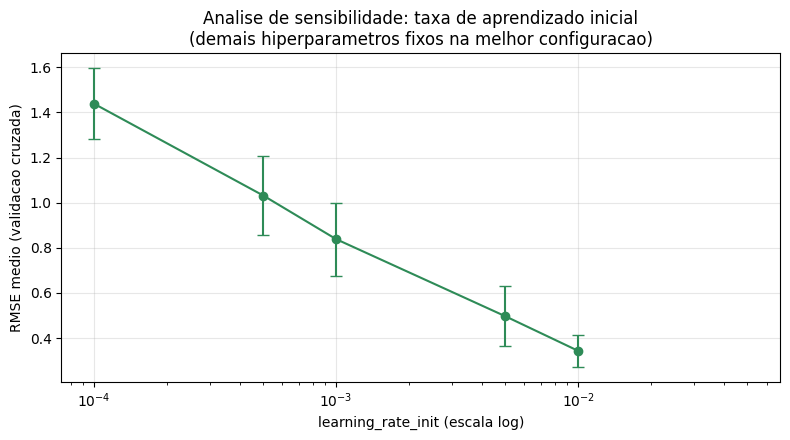

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(sens_df['learning_rate_init'], sens_df['rmse_mean'], yerr=sens_df['rmse_std'],
            marker='o', capsize=4, color='seagreen')
ax.set_xscale('log')
ax.set_xlabel('learning_rate_init (escala log)')
ax.set_ylabel('RMSE medio (validacao cruzada)')
ax.set_title('Analise de sensibilidade: taxa de aprendizado inicial\n(demais hiperparametros fixos na melhor configuracao)')
plt.tight_layout()
plt.show()


**Interpretação (baseada nos números obtidos nesta execução):**

A configuração-base é a melhor encontrada pelo TPE: 1 camada oculta com 16 neurônios, ReLU, otimizador **SGD**, batch 32.

| learning_rate_init | RMSE médio (CV) | desvio-padrão |
|---|---|---|
| 0,0001 | 1,438 | 0,158 |
| 0,0005 | 1,031 | 0,175 |
| 0,001  | 0,838 | 0,161 |
| 0,005  | 0,497 | 0,132 |
| 0,01   | 0,343 | 0,072 |
| 0,05   | divergiu (NaN nos 3 folds) | — |

O RMSE cai de forma monotônica e acentuada conforme a taxa de aprendizado aumenta de 1e-4 para 1e-2: de 1,438 para 0,343, mais de 4 vezes menor. Com taxas baixas, o SGD dá passos pequenos demais e o Early Stopping interrompe o treino antes de a rede convergir. É um caso de **underfitting por convergência incompleta**, não de falta de capacidade do modelo. O desvio-padrão entre folds também é maior nessa região (≈ 0,16 a 0,18), indicando treinos menos consistentes.

No outro extremo, com lr = 0,05, **o treino diverge** nos 3 folds: os pesos explodem e as previsões viram `NaN`. Isso é característico do SGD, que não adapta o tamanho do passo como o Adam. O mesmo problema derrubou os dois trials do TPE que falharam (SGD com lr ≈ 0,025 e ≈ 0,038). A curva tem, portanto, o formato clássico: taxa baixa demais leva a convergência lenta, e taxa alta demais leva a instabilidade. A taxa escolhida pelo TPE (≈ 0,0157, RMSE 0,278) fica entre 0,01 e 0,05, perto do limite de estabilidade, onde o SGD converge mais rápido sem divergir.

Esse padrão é **coerente com a importância estimada pelo TPE** (Seção 5): `learning_rate_init` foi de longe o hiperparâmetro mais importante segundo a análise fANOVA do Optuna (importância ≈ 0,75, muito acima do segundo colocado, `n_hidden_layers`, com ≈ 0,11). As duas análises apontam na mesma direção: uma global (importância estimada sobre toda a busca) e outra local (variação controlada em torno da melhor configuração). A taxa de aprendizado é o hiperparâmetro que mais determina o desempenho da MLP neste problema. A comparação desta análise com a versão feita na validação aleatória está na Seção 10.4.

## 8. Análise de Sensibilidade de Hiperparâmetros (individual — Paulo)

**Hiperparâmetro escolhido: `n_neurons` (número de neurônios em cada camada oculta).**

**Procedimento:** partindo da melhor configuração global encontrada (Random Search vs. TPE, a de menor RMSE), todos os demais hiperparâmetros são mantidos fixos, e apenas o número de neurônios é variado sistematicamente em 6 valores. A avaliação é feita com o mesmo `TimeSeriesSplit` de 3 folds e a mesma métrica RMSE usados nas buscas. Os valores testados incluem as quatro opções do espaço de busca e duas larguras intermediárias/ampliadas para observar melhor a tendência da capacidade da rede.

**Integrante responsável:** Paulo Ricardo da Rocha Cunha.

In [20]:
neuron_values = [16, 32, 48, 64, 128, 192]

neuron_sensitivity_results = []
for n_neurons in neuron_values:
    params = dict(best_overall)
    params['n_neurons'] = n_neurons
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressorFlexible(random_state=RANDOM_STATE, **params)),
    ])
    try:
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=1)
        rmse_mean, rmse_std = -scores.mean(), scores.std()
    except ValueError:  # todos os folds divergiram (ex.: sgd com lr alto -> NaN)
        rmse_mean, rmse_std = np.nan, np.nan
    neuron_sensitivity_results.append({
        'n_neurons': n_neurons,
        'rmse_mean': rmse_mean,
        'rmse_std': rmse_std,
    })
    print(f'n_neurons={n_neurons:<3} RMSE = {rmse_mean:.3f} +/- {rmse_std:.3f}')

neuron_sens_df = pd.DataFrame(neuron_sensitivity_results)
neuron_sens_df

n_neurons=16  RMSE = 0.278 +/- 0.064


n_neurons=32  RMSE = 0.405 +/- 0.141


n_neurons=48  RMSE = 0.399 +/- 0.106


n_neurons=64  RMSE = 0.487 +/- 0.205


n_neurons=128 RMSE = nan +/- nan


n_neurons=192 RMSE = 0.570 +/- 0.226


,n_neurons,rmse_mean,rmse_std
0,16,0.277783,0.064346
1,32,0.405265,0.140847
2,48,0.398511,0.106403
3,64,0.486915,0.204859
4,128,NaN,NaN
5,192,0.569664,0.225648


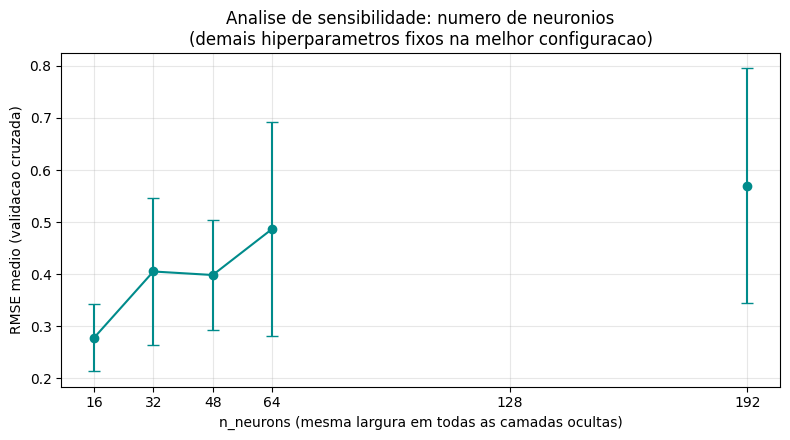

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(neuron_sens_df['n_neurons'], neuron_sens_df['rmse_mean'], yerr=neuron_sens_df['rmse_std'],
            marker='o', capsize=4, color='darkcyan')
ax.set_xlabel('n_neurons (mesma largura em todas as camadas ocultas)')
ax.set_ylabel('RMSE medio (validacao cruzada)')
ax.set_title('Analise de sensibilidade: numero de neuronios\n(demais hiperparametros fixos na melhor configuracao)')
ax.set_xticks(neuron_values)
plt.tight_layout()
plt.show()

**Resultados e interpretação:**

A configuração-base é a melhor encontrada pelo TPE: 1 camada oculta, ReLU, otimizador **SGD**, lr ≈ 0,0157, batch 32.

| `n_neurons` | RMSE médio (CV) | desvio-padrão |
|---:|---:|---:|
| 16  | 0,278 | 0,064 |
| 32  | 0,405 | 0,141 |
| 48  | 0,399 | 0,106 |
| 64  | 0,487 | 0,205 |
| 128 | divergiu (NaN nos 3 folds) | — |
| 192 | 0,570 | 0,226 |

O número de neurônios teve impacto forte e quase sempre negativo à medida que a camada fica mais larga. A configuração com 16 neurônios, que é a própria melhor configuração global, obteve o menor RMSE médio (0,278). Daí em diante, o erro sobe: 0,40 com 32 e 48 neurônios, 0,49 com 64 e 0,57 com 192. Com 128 neurônios o treino divergiu em todos os folds. O desvio-padrão entre folds também cresce com a largura (de 0,064 com 16 para 0,226 com 192), ou seja, redes mais largas ficaram não só piores, mas também muito mais instáveis.

A explicação mais provável é a interação com o otimizador. A taxa de aprendizado (≈ 0,0157) foi ajustada pelo TPE para uma rede com 16 neurônios usando SGD, que já opera perto do limite de estabilidade (Seção 7). Com mais neurônios, a camada de saída soma mais termos, os gradientes ficam maiores e o mesmo passo do SGD passa a ser grande demais, podendo chegar à divergência (128). O fato de 192 não ter divergido mostra que essa instabilidade também depende da inicialização aleatória dos pesos. Há ainda um efeito da validação temporal: o primeiro fold treina com poucos dados (≈ 1.800 amostras), e redes com mais parâmetros tendem a generalizar pior para um período futuro com tão pouco dado. A diferença entre 32 e 48 neurônios (0,405 vs. 0,399) está muito abaixo do desvio-padrão e não deve ser interpretada como tendência.

A comparação com a importância do TPE é **apenas parcialmente coerente**. Na análise fANOVA, `n_neurons` aparece só em 4º lugar (importância ≈ 0,045), enquanto a análise local mostrou variações de mais de 2 vezes no RMSE e até divergência. Isso acontece porque a importância global é uma média sobre todo o espaço de busca, onde o efeito da largura depende do otimizador e da taxa de aprendizado (com Adam ou taxas menores, o efeito é bem menor). Além disso, o TPE concentrou quase todos os seus melhores trials em 16 neurônios, o que dá pouca variação para estimar a importância desse parâmetro. Na região da melhor configuração (SGD com taxa alta), a largura da camada importa muito. A comparação desta análise com a versão feita na validação aleatória está na Seção 10.4.

## 9. Modelo final e avaliação no conjunto de teste (holdout)

O modelo final é treinado com a melhor configuração de hiperparâmetros encontrada (Random Search vs. TPE), agora em **todo o conjunto de treino** (sem a divisão em folds), e avaliado **uma única vez** no conjunto de teste (holdout) reservado na Seção 2.6, que não participou de nenhuma etapa de busca.

In [22]:
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressorFlexible(random_state=RANDOM_STATE, **best_overall)),
])
final_pipe.fit(X_train, y_train)

y_train_pred = final_pipe.predict(X_train)
y_test_pred = final_pipe.predict(X_test)

def report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label:>6} -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}')
    return {'conjunto': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

res_train = report(y_train, y_train_pred, 'Treino')
res_test = report(y_test, y_test_pred, 'Teste')

final_report = pd.DataFrame([res_train, res_test])
final_report


Treino -> MAE: 0.075 | RMSE: 0.102 | R2: 1.000
 Teste -> MAE: 0.123 | RMSE: 0.162 | R2: 0.999


,conjunto,MAE,RMSE,R2
0,Treino,0.075275,0.101836,0.999819
1,Teste,0.123448,0.162113,0.999381


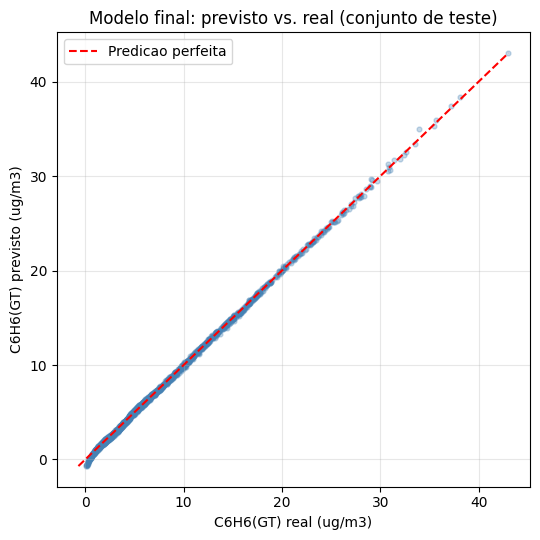

In [23]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, y_test_pred, alpha=0.3, s=12, color='steelblue')
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicao perfeita')
ax.set_xlabel('C6H6(GT) real (ug/m3)')
ax.set_ylabel('C6H6(GT) previsto (ug/m3)')
ax.set_title('Modelo final: previsto vs. real (conjunto de teste)')
ax.legend()
plt.tight_layout()
plt.show()


### Diagnóstico de overfitting / underfitting

**Resultado desta execução:** RMSE de treino = 0,102 e RMSE de teste = 0,162 (MAE 0,075 e 0,123; R² = 0,9998 e 0,9994). O erro no teste é cerca de 60% maior que no treino. Essa diferença **não indica overfitting clássico**: a rede escolhida é pequena (1 camada com 16 neurônios, ≈ 260 parâmetros para 7.192 amostras de treino) e os erros absolutos continuam muito baixos. A diferença vem principalmente de o teste ser um **período futuro** (16/01 a 04/04/2005) com outra distribuição da variável-alvo: concentração média de 7,9 µg/m³ no teste contra 10,6 no treino, com muito mais valores baixos. Isso é detalhado na Seção 10. Também não há underfitting: o erro médio absoluto de ≈ 0,12 µg/m³ é ínfimo diante de um alvo que varia de 0,1 a 63,7 µg/m³. No gráfico previsto vs. real, os pontos ficam sobre a diagonal; os maiores desvios relativos estão nas concentrações muito baixas, onde o modelo chega a prever alguns valores ligeiramente negativos.

O R² extremamente alto (~0,999) não é um erro nem um vazamento de dados: ele é explicado pela própria natureza do problema. O atributo `PT08.S2(NMHC)` é a leitura do sensor de baixo custo dedicado a compostos orgânicos voláteis (entre eles o benzeno) e é conhecido na literatura sobre este dataset por ser fortemente correlacionado com a concentração de referência `C6H6(GT)` (correlação de Pearson > 0,98). Ou seja, o problema de regressão tem, entre seus atributos, uma variável quase determinística do alvo. A MLP essencialmente aprende a calibrar essa leitura do sensor de baixo custo em relação ao analisador de referência, corrigindo pelo efeito das demais variáveis (outros gases, temperatura, umidade, padrões horários e sazonais). Esse é exatamente o problema real que motiva o dataset: substituir analisadores caros por sensores de baixo custo calibrados por modelo.

## 10. Comparação: modelo antigo (divisão aleatória) vs. modelo novo (divisão temporal)

Na versão anterior deste trabalho, tanto o holdout (`train_test_split(..., random_state=42)`) quanto a validação cruzada (`KFold(shuffle=True)`) **embaralhavam** os registros antes de dividi-los. Como os dados são uma série temporal horária, isso faz com que quase toda hora do teste/validação tenha a hora imediatamente anterior e/ou posterior no treino — e medições de horas vizinhas são muito parecidas. O modelo passa a ser avaliado em uma tarefa mais fácil do que a de uso real (prever o futuro a partir do passado).

Nesta seção o pipeline antigo é **reproduzido integralmente** (mesmo espaço de busca, Random Search + TPE com 25 configurações cada, escolha da melhor configuração, treino final e avaliação no holdout) e comparado com o pipeline novo das Seções 2.6 a 9. A única diferença entre os dois é a forma de dividir os dados:

| | Modelo antigo | Modelo novo |
|---|---|---|
| Holdout (teste) | 20% sorteados aleatoriamente (`random_state=42`) | 20% mais recentes (`shuffle=False`) |
| Validação cruzada | `KFold`, 3 folds, embaralhado | `TimeSeriesSplit`, 3 folds |
| Pré-processamento, espaço de busca, orçamento, métrica | iguais | iguais |

### 10.1. Diferenças nos dados de treino e teste

In [24]:
COR_TREINO, COR_TESTE = '#2a78d6', '#eb6834'
COR_ANTIGO, COR_NOVO = '#8c8c8c', '#1baf7a'

# Cenario antigo: mesma chamada da versao anterior do trabalho (holdout aleatorio) + KFold embaralhado
X_train_old, X_test_old, y_train_old, y_test_old, dt_train_old, dt_test_old = train_test_split(
    X, y, datetimes, test_size=0.2, random_state=RANDOM_STATE
)
cv_old = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Cenario novo: holdout temporal (Secao 2.6); o TimeSeriesSplit (Secao 3) ja esta em `cv`
dt_train_new, dt_test_new = datetimes.iloc[:len(X_train)], datetimes.iloc[len(X_train):]

def frac_teste_com_vizinho_no_treino(dt_tr, dt_te):
    """Fracao das horas de teste cuja hora anterior ou posterior esta no treino."""
    horas_treino = set(pd.DatetimeIndex(dt_tr))
    uma_hora = pd.Timedelta(hours=1)
    return np.mean([(t - uma_hora in horas_treino) or (t + uma_hora in horas_treino)
                    for t in pd.DatetimeIndex(dt_te)])

def resumo_split(nome, dt_tr, dt_te, y_tr, y_te):
    return {
        'cenario': nome,
        'n_treino': len(y_tr),
        'n_teste': len(y_te),
        'periodo_teste': f'{dt_te.min():%d/%m/%Y} a {dt_te.max():%d/%m/%Y}',
        'media_alvo_treino': y_tr.mean(),
        'media_alvo_teste': y_te.mean(),
        'dp_alvo_treino': y_tr.std(),
        'dp_alvo_teste': y_te.std(),
        'teste_com_vizinho_1h_no_treino_%': 100 * frac_teste_com_vizinho_no_treino(dt_tr, dt_te),
    }

split_summary = pd.DataFrame([
    resumo_split('Antigo (aleatorio)', dt_train_old, dt_test_old, y_train_old, y_test_old),
    resumo_split('Novo (temporal)', dt_train_new, dt_test_new, y_train, y_test),
]).set_index('cenario')
split_summary.round(2)

,n_treino,n_teste,periodo_teste,media_alvo_treino,media_alvo_teste,dp_alvo_treino,dp_alvo_teste,teste_com_vizinho_1h_no_treino_%
cenario,,,,,,,,
Antigo (aleatorio),7192,1799,10/03/2004 a 04/04/2005,10.00,10.43,7.41,7.58,95.22
Novo (temporal),7192,1799,16/01/2005 a 04/04/2005,10.64,7.86,7.56,6.51,0.06


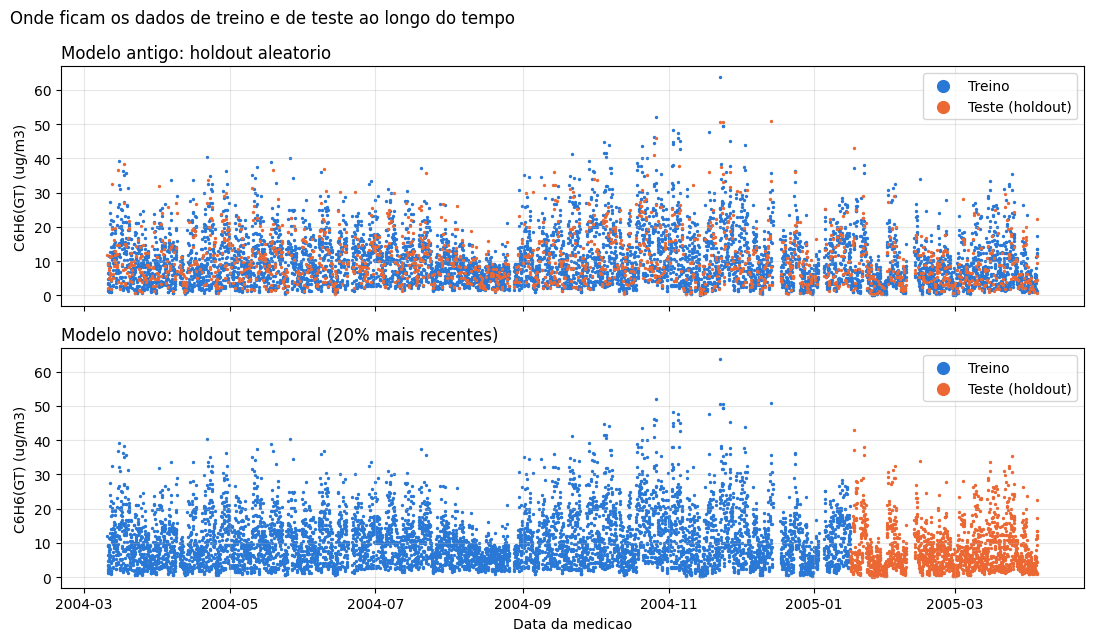

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, sharey=True)
cenarios_split = [
    (axes[0], 'Modelo antigo: holdout aleatorio', dt_train_old, dt_test_old, y_train_old, y_test_old),
    (axes[1], 'Modelo novo: holdout temporal (20% mais recentes)', dt_train_new, dt_test_new, y_train, y_test),
]
for ax, titulo, dt_tr, dt_te, y_tr, y_te in cenarios_split:
    ax.scatter(dt_tr, y_tr, s=2, color=COR_TREINO, label='Treino')
    ax.scatter(dt_te, y_te, s=2, color=COR_TESTE, label='Teste (holdout)')
    ax.set_title(titulo, loc='left')
    ax.set_ylabel('C6H6(GT) (ug/m3)')
    ax.legend(loc='upper right', markerscale=6)
axes[1].set_xlabel('Data da medicao')
fig.suptitle('Onde ficam os dados de treino e de teste ao longo do tempo', x=0.01, ha='left')
plt.tight_layout()
plt.show()

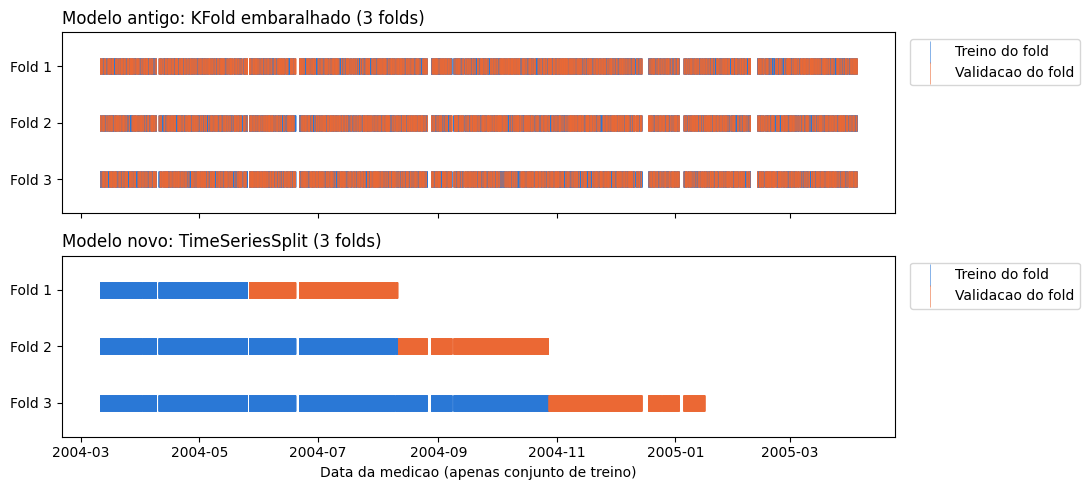

In [26]:
def plot_folds(ax, cv_, dt_tr, titulo):
    dt_tr = pd.Series(pd.DatetimeIndex(dt_tr))
    for i, (idx_tr, idx_val) in enumerate(cv_.split(dt_tr)):
        ax.scatter(dt_tr.iloc[idx_tr], np.full(len(idx_tr), i + 1), marker='|', s=120,
                   linewidths=0.4, color=COR_TREINO, label='Treino do fold' if i == 0 else None)
        ax.scatter(dt_tr.iloc[idx_val], np.full(len(idx_val), i + 1), marker='|', s=120,
                   linewidths=0.4, color=COR_TESTE, label='Validacao do fold' if i == 0 else None)
    ax.set_yticks([1, 2, 3], ['Fold 1', 'Fold 2', 'Fold 3'])
    ax.set_ylim(0.4, 3.6)
    ax.invert_yaxis()
    ax.set_title(titulo, loc='left')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), markerscale=1.5)
    ax.grid(False)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
plot_folds(axes[0], cv_old, dt_train_old, 'Modelo antigo: KFold embaralhado (3 folds)')
plot_folds(axes[1], cv, dt_train_new, 'Modelo novo: TimeSeriesSplit (3 folds)')
axes[1].set_xlabel('Data da medicao (apenas conjunto de treino)')
plt.tight_layout()
plt.show()

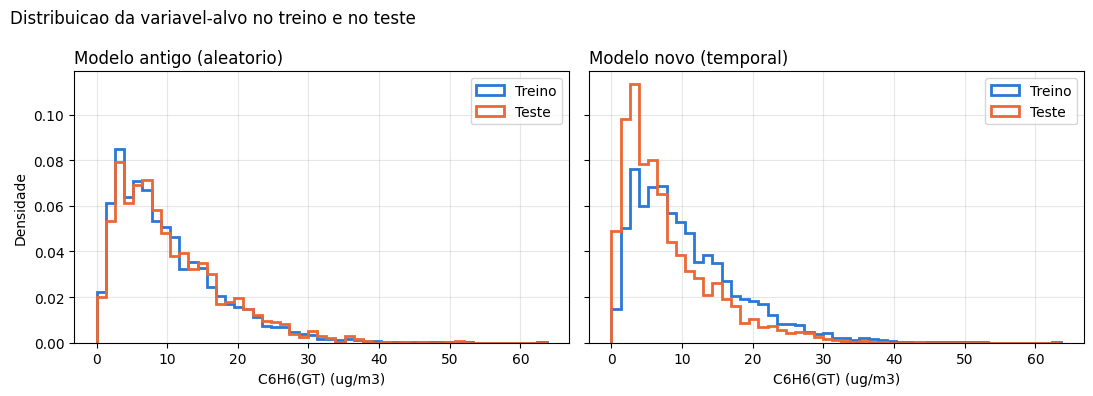

In [27]:
bins = np.linspace(0, y.max(), 50)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (titulo, y_tr, y_te) in zip(axes, [
        ('Modelo antigo (aleatorio)', y_train_old, y_test_old),
        ('Modelo novo (temporal)', y_train, y_test)]):
    ax.hist(y_tr, bins=bins, density=True, histtype='step', linewidth=2, color=COR_TREINO, label='Treino')
    ax.hist(y_te, bins=bins, density=True, histtype='step', linewidth=2, color=COR_TESTE, label='Teste')
    ax.set_title(titulo, loc='left')
    ax.set_xlabel('C6H6(GT) (ug/m3)')
    ax.legend()
axes[0].set_ylabel('Densidade')
fig.suptitle('Distribuicao da variavel-alvo no treino e no teste', x=0.01, ha='left')
plt.tight_layout()
plt.show()

**Diferenças nos dados:**

- **Vizinhança temporal entre treino e teste.** No modelo antigo, **95,2%** das horas do teste têm a hora anterior e/ou a posterior no treino (gráfico de cima: pontos laranja espalhados entre os azuis). No modelo novo, isso cai para **0,06%** — apenas a primeira hora do teste, que encosta na última hora do treino. Ou seja, o teste antigo era quase uma tarefa de **interpolação** (preencher horas faltantes no meio de dados conhecidos), enquanto o teste novo é de **extrapolação no tempo** (prever um período ainda não visto).
- **Período coberto pelo teste.** O teste antigo cobre o ano inteiro (10/03/2004 a 04/04/2005); o novo cobre apenas **16/01/2005 a 04/04/2005** (fim do inverno e início da primavera).
- **Distribuição da variável-alvo.** Na divisão aleatória, treino e teste têm praticamente a mesma distribuição (média 10,00 vs. 10,43 µg/m³; desvio-padrão 7,41 vs. 7,58), como se vê nos histogramas quase sobrepostos. Na divisão temporal há uma **mudança de distribuição**: o teste tem média menor (7,86 vs. 10,64 µg/m³), menor dispersão (6,51 vs. 7,56) e muito mais concentrações baixas (pico do histograma laranja entre 2 e 4 µg/m³). O modelo novo é avaliado em condições diferentes das que viu no treino, como aconteceria em uso real.
- **Folds da validação cruzada.** No `KFold` embaralhado, cada fold valida em horas intercaladas com as de treino (as faixas azul e laranja se misturam ao longo do ano todo). No `TimeSeriesSplit`, cada fold treina em um bloco inicial e valida no bloco seguinte. O fold 1 treina só com ~2,5 meses (mar–mai/2004) e valida em jun–ago/2004, meses e condições que o modelo nunca viu. Isso torna a validação cruzada temporal mais difícil e mais variável.

### 10.2. Reprodução do modelo antigo

Mesmas buscas das Seções 4 e 5 (Random Search e TPE, 25 configurações cada, mesmas sementes), agora sobre o treino aleatório e com `KFold` embaralhado. A melhor das duas buscas é treinada em todo o treino aleatório e avaliada no holdout aleatório — exatamente o procedimento da versão anterior. **Esta célula repete as duas buscas e leva alguns minutos.**

In [28]:
t0 = time.time()
rs_old = RandomizedSearchCV(
    make_flex_pipeline(), param_distributions, n_iter=25, cv=cv_old,
    scoring=SCORING, random_state=RANDOM_STATE, n_jobs=1, refit=False, verbose=0,
)
rs_old.fit(X_train_old, y_train_old)

study_old = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_old.optimize(make_objective(X_train_old, y_train_old, cv_old), n_trials=25,
                   show_progress_bar=False, catch=(ValueError,))
print(f'Buscas do modelo antigo concluidas em {time.time() - t0:.1f}s')
print(f'Random Search -> melhor RMSE (CV): {-rs_old.best_score_:.4f}')
print(f'TPE           -> melhor RMSE (CV): {study_old.best_value:.4f}')

best_rs_old = {k.replace('mlp__', ''): v for k, v in rs_old.best_params_.items()}
if -rs_old.best_score_ <= study_old.best_value:
    best_old, best_old_source, best_old_cv = best_rs_old, 'Random Search', -rs_old.best_score_
else:
    best_old, best_old_source, best_old_cv = dict(study_old.best_params), 'TPE', study_old.best_value
best_new_cv = min(-random_search.best_score_, study.best_value)

def make_final_pipe(params):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressorFlexible(random_state=RANDOM_STATE, **params)),
    ])

final_old = make_final_pipe(best_old).fit(X_train_old, y_train_old)

pd.DataFrame({
    f'Antigo ({best_old_source})': pd.Series(best_old),
    f'Novo ({best_overall_source})': pd.Series(best_overall),
})

[W 2026-09-30 21:20:28,419] Trial 20 failed with parameters: {'n_hidden_layers': 1, 'n_neurons': 32, 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.040425622412796194, 'batch_size': 32, 'n_iter_no_change': 15} because of the following error: ValueError('\nAll the 3 fits failed.\nIt is very likely that your model is misconfigured.\nYou can try to debug the error by setting error_score=\'raise\'.\n\nBelow are more details about the failures:\n--------------------------------------------------------------------------------\n3 fits failed with the following error:\nTraceback (most recent call last):\n  File "C:\\Users\\paulo\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\sklearn\\model_selection\\_validation.py", line 895, in _fit_and_score\n    estimator.fit(X_train, y_train, **fit_params)\n  File "C:\\Users\\paulo\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra

[W 2026-09-30 21:20:28,420] Trial 20 failed with value None.


Buscas do modelo antigo concluidas em 391.0s
Random Search -> melhor RMSE (CV): 0.1139
TPE           -> melhor RMSE (CV): 0.1168


,Antigo (Random Search),Novo (TPE)
activation,relu,relu
batch_size,32,32
learning_rate_init,0.012141,0.015667
n_hidden_layers,3,1
n_iter_no_change,15,10
n_neurons,64,16
solver,adam,sgd


### 10.3. Comparação dos resultados

Além dos dois modelos, a tabela inclui uma terceira linha: a **configuração escolhida pelo modelo antigo, retreinada e avaliada no esquema temporal** (mesmo treino, `TimeSeriesSplit` e holdout do modelo novo). Ela separa os dois efeitos da mudança: quanto da diferença vem da **forma de avaliar** (mesma configuração, divisão diferente) e quanto vem da **escolha de hiperparâmetros** feita por cada esquema de validação.

In [29]:
old_cfg_temporal = make_final_pipe(best_old).fit(X_train, y_train)
old_cfg_temporal_cv = -cross_val_score(make_final_pipe(best_old), X_train, y_train,
                                       cv=cv, scoring=SCORING, n_jobs=1).mean()

def linha_resultado(nome, cv_rmse, pipe_, X_tr, y_tr, X_te, y_te):
    pred_tr, pred_te = pipe_.predict(X_tr), pipe_.predict(X_te)
    return {
        'modelo': nome,
        'RMSE_CV': cv_rmse,
        'RMSE_treino': root_mean_squared_error(y_tr, pred_tr),
        'RMSE_teste': root_mean_squared_error(y_te, pred_te),
        'MAE_teste': mean_absolute_error(y_te, pred_te),
        'R2_teste': r2_score(y_te, pred_te),
    }

comparison_results = pd.DataFrame([
    linha_resultado('Antigo (aleatorio)', best_old_cv, final_old,
                    X_train_old, y_train_old, X_test_old, y_test_old),
    linha_resultado('Novo (temporal)', best_new_cv, final_pipe,
                    X_train, y_train, X_test, y_test),
    linha_resultado('Config. antiga no esquema temporal', old_cfg_temporal_cv, old_cfg_temporal,
                    X_train, y_train, X_test, y_test),
]).set_index('modelo')
comparison_results['teste / CV'] = comparison_results['RMSE_teste'] / comparison_results['RMSE_CV']
comparison_results.round(4)

,RMSE_CV,RMSE_treino,RMSE_teste,MAE_teste,R2_teste,teste / CV
modelo,,,,,,
Antigo (aleatorio),0.1139,0.0947,0.1007,0.0686,0.9998,0.8838
Novo (temporal),0.2778,0.1018,0.1621,0.1234,0.9994,0.5836
Config. antiga no esquema temporal,0.2875,0.0898,0.1363,0.1021,0.9996,0.4743


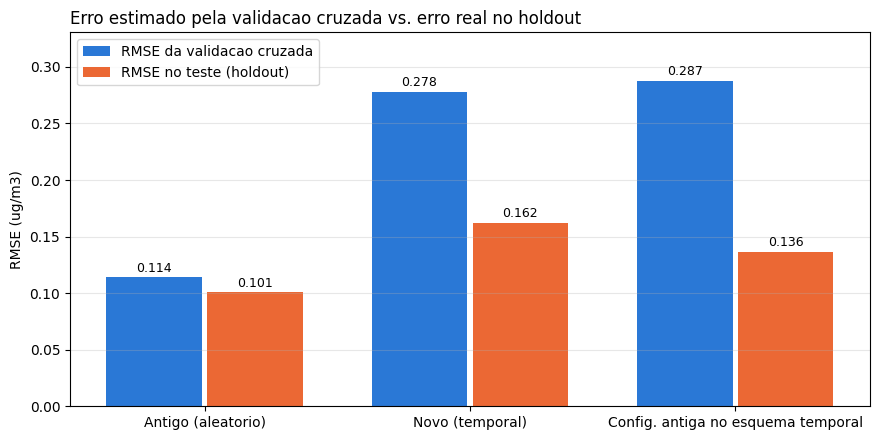

In [30]:
fig, ax = plt.subplots(figsize=(9, 4.5))
pos = np.arange(len(comparison_results))
largura = 0.36
barras_cv = ax.bar(pos - largura / 2 - 0.01, comparison_results['RMSE_CV'], largura,
                   color=COR_TREINO, label='RMSE da validacao cruzada')
barras_te = ax.bar(pos + largura / 2 + 0.01, comparison_results['RMSE_teste'], largura,
                   color=COR_TESTE, label='RMSE no teste (holdout)')
for barras in (barras_cv, barras_te):
    ax.bar_label(barras, fmt='%.3f', padding=2, fontsize=9)
ax.set_xticks(pos, comparison_results.index)
ax.set_ylabel('RMSE (ug/m3)')
ax.set_title('Erro estimado pela validacao cruzada vs. erro real no holdout', loc='left')
ax.legend(loc='upper left')
ax.grid(axis='x', visible=False)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

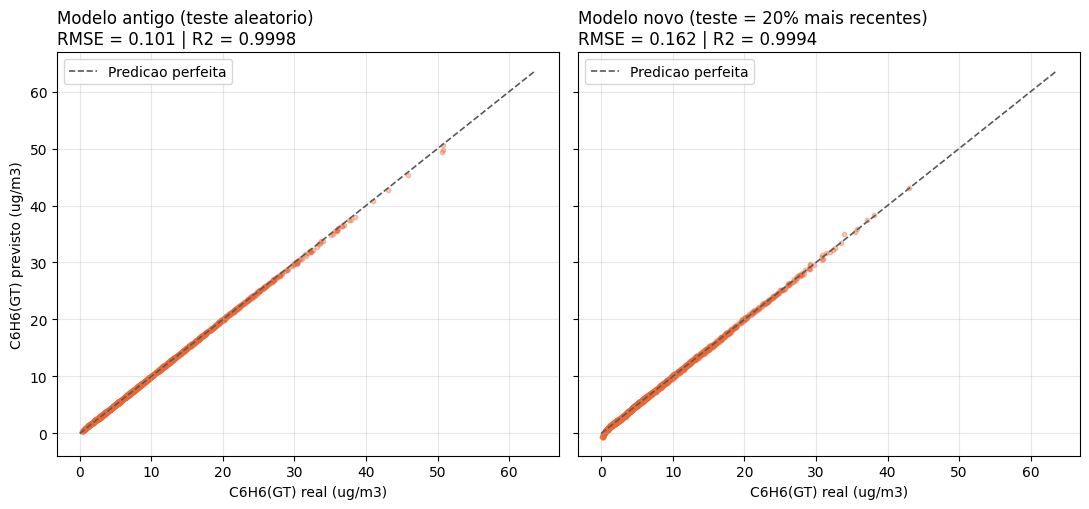

In [31]:
pred_test_old = final_old.predict(X_test_old)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharex=True, sharey=True)
for ax, (titulo, y_te, pred) in zip(axes, [
        ('Modelo antigo (teste aleatorio)', y_test_old, pred_test_old),
        ('Modelo novo (teste = 20% mais recentes)', y_test, y_test_pred)]):
    ax.scatter(y_te, pred, s=10, alpha=0.35, color=COR_TESTE)
    lims = [0, max(y.max(), pred.max())]
    ax.plot(lims, lims, color='0.35', linestyle='--', linewidth=1.2, label='Predicao perfeita')
    rmse = root_mean_squared_error(y_te, pred)
    ax.set_title(f'{titulo}\nRMSE = {rmse:.3f} | R2 = {r2_score(y_te, pred):.4f}', loc='left')
    ax.set_xlabel('C6H6(GT) real (ug/m3)')
    ax.legend(loc='upper left')
axes[0].set_ylabel('C6H6(GT) previsto (ug/m3)')
plt.tight_layout()
plt.show()

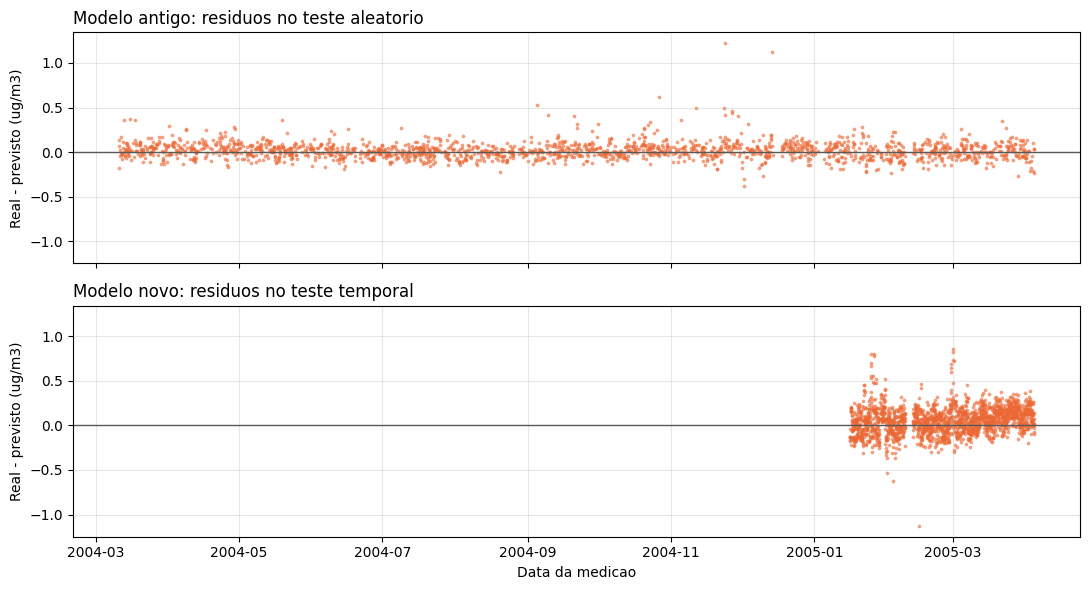

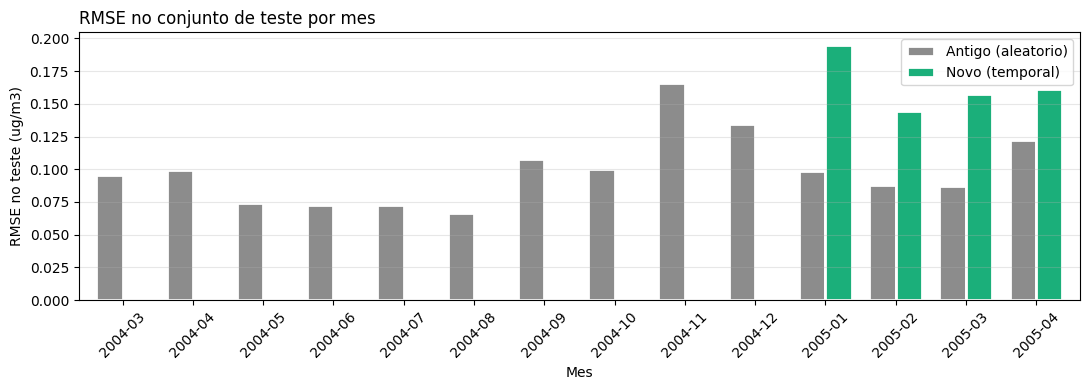

,Antigo (aleatorio),Novo (temporal)
data,,
2004-03,0.096,NaN
2004-04,0.100,NaN
2004-05,0.074,NaN
2004-06,0.073,NaN
2004-07,0.073,NaN
2004-08,0.067,NaN
2004-09,0.108,NaN
2004-10,0.100,NaN
2004-11,0.166,NaN


In [32]:
res_old = pd.DataFrame({'data': pd.DatetimeIndex(dt_test_old), 'residuo': y_test_old - pred_test_old})
res_new = pd.DataFrame({'data': pd.DatetimeIndex(dt_test_new), 'residuo': y_test - y_test_pred})

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, sharey=True)
for ax, (titulo, res) in zip(axes, [('Modelo antigo: residuos no teste aleatorio', res_old),
                                     ('Modelo novo: residuos no teste temporal', res_new)]):
    ax.axhline(0, color='0.35', linewidth=1)
    ax.scatter(res['data'], res['residuo'], s=3, alpha=0.5, color=COR_TESTE)
    ax.set_title(titulo, loc='left')
    ax.set_ylabel('Real - previsto (ug/m3)')
axes[1].set_xlabel('Data da medicao')
plt.tight_layout()
plt.show()

def rmse_por_mes(res):
    return res.groupby(res['data'].dt.to_period('M'))['residuo'].apply(lambda r: np.sqrt(np.mean(r ** 2)))

rmse_mes = pd.DataFrame({'Antigo (aleatorio)': rmse_por_mes(res_old),
                         'Novo (temporal)': rmse_por_mes(res_new)})
fig, ax = plt.subplots(figsize=(11, 4))
rmse_mes.plot(kind='bar', ax=ax, color=[COR_ANTIGO, COR_NOVO], width=0.75, edgecolor='white', linewidth=2)
ax.set_xlabel('Mes')
ax.set_ylabel('RMSE no teste (ug/m3)')
ax.set_title('RMSE no conjunto de teste por mes', loc='left')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()
rmse_mes.round(3)

### 10.4. Impacto nas análises de sensibilidade individuais (Rafael e Paulo)

As análises das Seções 7 (`learning_rate_init`, Rafael) e 8 (`n_neurons`, Paulo) são repetidas aqui no esquema antigo, com os mesmos valores testados, partindo da melhor configuração antiga e usando o treino aleatório com `KFold` embaralhado. Assim é possível compará-las com as versões novas das Seções 7 e 8.

Como no item 10.3, também é incluído um terceiro cenário: a **configuração antiga avaliada com `TimeSeriesSplit`**. Isso é necessário porque as análises antiga e nova partem de configurações-base diferentes (3 × 64 com Adam no antigo; 1 × 16 com SGD no novo). O terceiro cenário mostra o que muda apenas pela forma de validar, mantendo a configuração-base fixa. **Esta célula repete 24 validações cruzadas e leva alguns minutos.**

In [33]:
def sensibilidade(base_params, nome_param, valores, X_tr, y_tr, cv_):
    linhas = []
    for v in valores:
        params = dict(base_params)
        params[nome_param] = v
        try:
            scores = cross_val_score(make_final_pipe(params), X_tr, y_tr, cv=cv_, scoring=SCORING, n_jobs=1)
            rmse_mean, rmse_std = -scores.mean(), scores.std()
        except ValueError:  # todos os folds divergiram
            rmse_mean, rmse_std = np.nan, np.nan
        linhas.append({nome_param: v, 'rmse_mean': rmse_mean, 'rmse_std': rmse_std})
    return pd.DataFrame(linhas)

t0 = time.time()
sens_lr = {
    'Antigo (aleatorio)': sensibilidade(best_old, 'learning_rate_init', lr_values, X_train_old, y_train_old, cv_old),
    'Novo (temporal)': sens_df,
    'Config. antiga no esquema temporal': sensibilidade(best_old, 'learning_rate_init', lr_values, X_train, y_train, cv),
}
sens_n = {
    'Antigo (aleatorio)': sensibilidade(best_old, 'n_neurons', neuron_values, X_train_old, y_train_old, cv_old),
    'Novo (temporal)': neuron_sens_df,
    'Config. antiga no esquema temporal': sensibilidade(best_old, 'n_neurons', neuron_values, X_train, y_train, cv),
}
print(f'Analises de sensibilidade do esquema antigo concluidas em {time.time() - t0:.1f}s')

def tabela_sensibilidade(resultados, nome_param):
    tabela = pd.concat({nome: df.set_index(nome_param)['rmse_mean'] for nome, df in resultados.items()}, axis=1)
    melhor = tabela.idxmin().rename('melhor valor')
    return tabela, melhor

tab_lr, melhor_lr = tabela_sensibilidade(sens_lr, 'learning_rate_init')
tab_n, melhor_n = tabela_sensibilidade(sens_n, 'n_neurons')
print('\nRMSE medio (CV) por learning_rate_init (Rafael):')
display(tab_lr.round(3))
print('Melhor learning_rate_init em cada cenario:')
display(melhor_lr.to_frame())
print('\nRMSE medio (CV) por n_neurons (Paulo):')
display(tab_n.round(3))
print('Melhor n_neurons em cada cenario:')
display(melhor_n.to_frame())

Analises de sensibilidade do esquema antigo concluidas em 363.5s

RMSE medio (CV) por learning_rate_init (Rafael):


,Antigo (aleatorio),Novo (temporal),Config. antiga no esquema temporal
learning_rate_init,,,
0.0001,0.329,1.438,1.401
0.0005,0.203,1.031,0.993
0.0010,0.206,0.838,1.036
0.0050,0.111,0.497,0.648
0.0100,0.126,0.343,0.470
0.0500,0.161,NaN,0.349


Melhor learning_rate_init em cada cenario:


,melhor valor
Antigo (aleatorio),0.005
Novo (temporal),0.010
Config. antiga no esquema temporal,0.050



RMSE medio (CV) por n_neurons (Paulo):


,Antigo (aleatorio),Novo (temporal),Config. antiga no esquema temporal
n_neurons,,,
16,0.105,0.278,0.413
32,0.137,0.405,0.578
48,0.109,0.399,0.508
64,0.114,0.487,0.287
128,0.179,NaN,0.566
192,0.126,0.570,0.702


Melhor n_neurons em cada cenario:


,melhor valor
Antigo (aleatorio),16
Novo (temporal),16
Config. antiga no esquema temporal,64


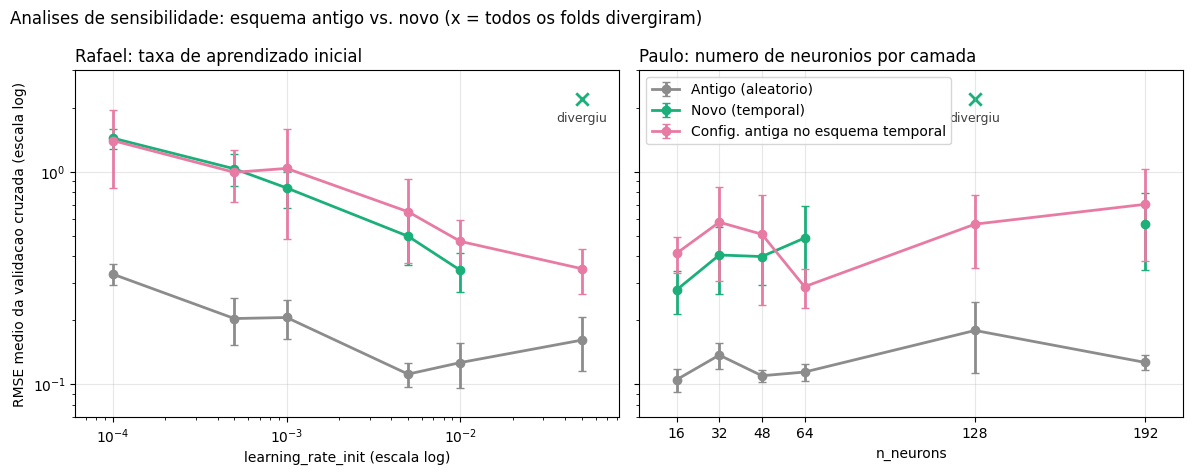

In [34]:
COR_CFG_ANTIGA_TEMPORAL = '#e87ba4'
cores_cenario = {'Antigo (aleatorio)': COR_ANTIGO, 'Novo (temporal)': COR_NOVO,
                 'Config. antiga no esquema temporal': COR_CFG_ANTIGA_TEMPORAL}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
paineis = [
    (axes[0], sens_lr, 'learning_rate_init', 'learning_rate_init (escala log)', 'Rafael: taxa de aprendizado inicial'),
    (axes[1], sens_n, 'n_neurons', 'n_neurons', 'Paulo: numero de neuronios por camada'),
]
for ax, resultados, nome_param, xlabel, titulo in paineis:
    for nome, df_s in resultados.items():
        ax.errorbar(df_s[nome_param], df_s['rmse_mean'], yerr=df_s['rmse_std'], marker='o', markersize=6,
                    capsize=3, linewidth=2, color=cores_cenario[nome], label=nome)
        for v in df_s.loc[df_s['rmse_mean'].isna(), nome_param]:
            ax.scatter(v, 2.2, marker='x', s=80, linewidths=2, color=cores_cenario[nome])
            ax.annotate('divergiu', (v, 2.2), textcoords='offset points', xytext=(0, -16),
                        ha='center', fontsize=9, color='0.25')
    if nome_param == 'learning_rate_init':
        ax.set_xscale('log')
    else:
        ax.set_xticks(neuron_values)
    ax.margins(x=0.08)
    ax.set_xlabel(xlabel)
    ax.set_title(titulo, loc='left')
axes[0].set_yscale('log')
axes[0].set_ylim(0.07, 3)
axes[0].set_ylabel('RMSE medio da validacao cruzada (escala log)')
axes[1].legend(loc='upper left')
fig.suptitle('Analises de sensibilidade: esquema antigo vs. novo (x = todos os folds divergiram)', x=0.01, ha='left')
plt.tight_layout()
plt.show()

**Diferenças nas análises individuais:**

**Rafael — `learning_rate_init`**

| learning_rate_init | Antigo (aleatório) | Novo (temporal) | Config. antiga no esquema temporal |
|---|---|---|---|
| 0,0001 | 0,329 | 1,438 | 1,401 |
| 0,0005 | 0,203 | 1,031 | 0,993 |
| 0,001  | 0,206 | 0,838 | 1,036 |
| 0,005  | **0,111** | 0,497 | 0,648 |
| 0,01   | 0,126 | **0,343** | 0,470 |
| 0,05   | 0,161 | divergiu | **0,349** |

- **A conclusão principal se mantém:** nos três cenários, a taxa de aprendizado é decisiva e taxas baixas (1e-4 a 1e-3) são sempre as piores.
- **No esquema antigo, a curva era muito mais plana:** o RMSE variava só de 0,111 a 0,329 (≈ 3 vezes). No temporal, com a mesma configuração-base, varia de 0,349 a 1,401 (≈ 4 vezes), e com taxa 1e-4 o erro é ≈ 4,3 vezes maior que no antigo. A validação temporal penaliza muito mais a convergência lenta. Uma razão provável é que os primeiros folds têm poucos dados, ou seja, menos atualizações de peso por época antes do Early Stopping, e ainda precisam generalizar para outra estação do ano.
- **A melhor taxa muda com o esquema de validação.** Com a mesma configuração (3 × 64, Adam), a melhor taxa era 0,005 no esquema antigo (e 0,05 piorava o resultado), mas no temporal é 0,05, a maior testada, e a curva ainda está caindo. A recomendação de taxa de aprendizado da análise antiga não vale no cenário de previsão real.
- **A divergência em lr = 0,05 no modelo novo vem do otimizador, não da validação.** A configuração antiga, com Adam, não diverge com lr = 0,05 em nenhum esquema; a nova, com SGD, diverge. O Adam adapta o tamanho do passo de cada peso e é bem mais tolerante a taxas altas.

**Paulo — `n_neurons`**

| `n_neurons` | Antigo (aleatório) | Novo (temporal) | Config. antiga no esquema temporal |
|---:|---:|---:|---:|
| 16  | **0,105** | **0,278** | 0,413 |
| 32  | 0,137 | 0,405 | 0,578 |
| 48  | 0,109 | 0,399 | 0,508 |
| 64  | 0,114 | 0,487 | **0,287** |
| 128 | 0,179 | divergiu | 0,566 |
| 192 | 0,126 | 0,570 | 0,702 |

- **No esquema antigo, a largura parecia ter impacto moderado:** quase todos os valores ficavam entre 0,105 e 0,137, exceto 128 (0,179), com desvios-padrão pequenos. No temporal, o impacto é muito maior (≈ 2,0 a 2,4 vezes entre o melhor e o pior valor nos dois cenários temporais), e os desvios-padrão entre folds são bem maiores (até ≈ 0,23).
- **"16 neurônios é o melhor" aparece no antigo e no novo, mas por razões diferentes.** No antigo, 16, 48 e 64 eram praticamente equivalentes (0,105 a 0,114). No novo, 16 é claramente melhor porque a configuração-base usa SGD com taxa alta, e redes mais largas ficam instáveis, chegando a divergir em 128.
- **Com a configuração antiga no esquema temporal, o melhor valor passa a ser 64,** justamente a largura original daquela configuração; mudar a largura em qualquer direção piora bastante o resultado (0,413 a 0,702). No esquema temporal, os hiperparâmetros ficam fortemente acoplados: a largura ótima depende da taxa de aprendizado e do número de camadas com que foi ajustada, e mexer em um só deles isoladamente custa caro. No esquema aleatório, a interpolação entre horas vizinhas era fácil o suficiente para mascarar essas interações.

**Em resumo:** a forma de validar muda as conclusões das análises individuais, e não só os números. A validação aleatória produzia curvas mais planas e erros cerca de 3 a 4 vezes menores, sugerindo que o modelo era pouco sensível aos hiperparâmetros. A validação temporal mostra que a escolha de taxa de aprendizado e largura é bem mais crítica e que o valor ótimo pode mudar (lr: 0,005 → 0,05 para a mesma configuração). Os números da análise do Rafael na versão anterior do trabalho (ex.: 0,115 com lr = 0,05) não coincidem com a reprodução acima (0,161) porque vieram de uma execução diferente, provavelmente com outra configuração-base. Os da análise do Paulo são reproduzidos exatamente (0,105; 0,137; 0,109; 0,114; 0,179; 0,126).

### 10.5. Principais diferenças encontradas

| | Modelo antigo (aleatório) | Modelo novo (temporal) | Config. antiga no esquema temporal |
|---|---|---|---|
| Configuração escolhida | Random Search: 3 camadas × 64, Adam, lr ≈ 0,012 | TPE: 1 camada × 16, SGD, lr ≈ 0,016 | (a mesma do modelo antigo) |
| RMSE da validação cruzada | 0,114 | 0,278 | 0,287 |
| RMSE de treino | 0,095 | 0,102 | 0,090 |
| **RMSE de teste** | **0,101** | **0,162** | **0,136** |
| MAE de teste | 0,069 | 0,123 | 0,102 |
| R² de teste | 0,9998 | 0,9994 | 0,9996 |

**1. O modelo antigo superestimava o desempenho.** Com a mesma rede, os mesmos dados e o mesmo procedimento, o erro no holdout sobe de RMSE 0,101 para 0,162 (+61%) e o MAE quase dobra (0,069 → 0,123 µg/m³) quando o teste passa a ser o período mais recente. A causa principal é a vizinhança temporal mostrada na Seção 10.1: 95% das horas do teste antigo tinham uma hora vizinha, quase idêntica, no treino. O resultado antigo media a capacidade de interpolar, não a de prever o futuro.

**2. Parte da diferença vem da forma de avaliar, parte da escolha de hiperparâmetros.** A terceira coluna mantém a configuração antiga e muda só a avaliação: o RMSE de teste vai de 0,101 para 0,136 (+35%). Esse é o efeito puro da forma de avaliar. O restante (0,136 → 0,162) vem da configuração escolhida pela validação temporal (rede menor, 1 × 16 com SGD), que foi **pior** no holdout do que a configuração antiga. Isso não invalida a validação temporal, mas mostra uma limitação dela com apenas 3 folds: a diferença entre as duas configurações na validação cruzada (0,278 vs. 0,287) é muito menor que o desvio-padrão entre folds (~0,06). O fold 1, treinado com poucos dados, pesa muito na média e tende a favorecer redes pequenas, que aprendem rápido com pouco dado. Aumentar `n_splits` (ex.: 5) deixaria a seleção mais estável.

**3. A relação entre validação cruzada e teste mudou.** No modelo antigo, CV e teste concordam (0,114 vs. 0,101), porque ambos são tarefas de interpolação. No modelo novo, a CV é **pessimista** (0,278 vs. 0,162 no teste): nos folds iniciais o modelo treina com poucos meses e valida em estações nunca vistas, enquanto o modelo final treina com 10 meses de dados. A validação temporal serve para comparar configurações entre si; a estimativa mais fiel do erro em uso real é o RMSE do holdout temporal (0,162).

**4. Aparece uma diferença entre treino e teste que a divisão aleatória escondia.** No modelo antigo, treino e teste têm erros praticamente iguais (0,095 vs. 0,101), o que levava à conclusão de "nenhum overfitting". No modelo novo, o teste tem erro ~60% maior que o treino (0,102 vs. 0,162). Isso não é overfitting clássico (a rede escolhida é pequena); é a perda de desempenho ao generalizar para um período futuro, com outra distribuição de concentrações (Seção 10.1).

**5. O erro não é uniforme no tempo.** Nos mesmos meses (jan–abr/2005), o RMSE mensal do modelo novo (0,14 a 0,19) fica sempre acima do antigo (0,09 a 0,12). Os resíduos do modelo novo têm um viés positivo que cresce em março e abril (o modelo passa a subestimar a concentração real) e há previsões negativas, fisicamente impossíveis, nas concentrações muito baixas, que são mais frequentes no período de teste. Esses padrões só aparecem na avaliação temporal e indicam que a relação entre sensores e concentração muda com a estação. Na prática, isso sugeriria retreinar o modelo periodicamente.

**6. O R² quase não muda e, sozinho, esconde a diferença.** O R² cai só de 0,9998 para 0,9994, porque a variância do alvo (desvio-padrão ~7 µg/m³) é muito maior que os erros. Por isso as comparações devem ser feitas com RMSE e MAE.

**7. As análises de sensibilidade individuais mudam de conclusão.** Como detalhado na Seção 10.4, a validação aleatória dava curvas mais planas (o modelo parecia pouco sensível aos hiperparâmetros). A temporal mostra efeitos maiores, instabilidade com SGD e uma taxa de aprendizado ótima diferente para a mesma configuração.

**Conclusão:** em termos absolutos, o modelo continua excelente (erro médio absoluto de ~0,12 µg/m³ em um alvo de 0 a 63,7 µg/m³), graças à forte relação entre `PT08.S2(NMHC)` e o benzeno (Seção 9). Mas o desempenho real, prevendo dados futuros, é cerca de 60% pior do que a divisão aleatória indicava. A divisão temporal é a forma correta de avaliar este problema, e seus números são os que devem ser reportados.

*Observação:* a reprodução do modelo antigo nesta seção obteve RMSE de teste 0,101, e não o 0,073 citado na versão anterior do trabalho. As saídas daquela versão vinham de execuções diferentes (por exemplo, a Seção 5 mostrava melhor RMSE do TPE 0,1168 em uma célula e 0,1135 em outra), então a configuração final usada naquela execução não é recuperável com certeza. Aqui, todo o procedimento antigo é executado de ponta a ponta, na mesma execução do modelo novo.

## 11. Discussão crítica dos resultados

**Protocolo de avaliação (holdout e validação cruzada temporais):** como o dataset é uma série temporal horária, o holdout usa os 20% de registros mais recentes e a validação cruzada usa `TimeSeriesSplit`. A Seção 10 mostra que essa escolha é essencial. A versão anterior do trabalho, com divisões aleatórias, colocava no treino uma hora vizinha de 95% das horas de teste e **superestimava o desempenho**: o RMSE de teste era 0,101 contra 0,162 no esquema temporal (+61%). Ela também levava a conclusões diferentes nas análises de sensibilidade. Todos os números desta discussão referem-se ao esquema temporal.

**Random Search vs. TPE, mesmo orçamento (25 configurações):** o TPE encontrou a melhor configuração (RMSE de CV 0,2778 vs. 0,2875 do Random Search) e foi mais rápido. A diferença, porém, é bem menor que o desvio-padrão entre folds (≈ 0,06), então não permite afirmar que o TPE seja superior em geral. Dois trials do TPE divergiram (SGD com taxa de aprendizado alta) e foram ignorados para que o orçamento de 25 trials fosse concluído. Isso reforça a necessidade de considerar a estabilidade numérica ao definir o espaço de busca.

**Hiperparâmetros de maior impacto:** a importância estimada pelo TPE (≈ 0,75) e a análise de sensibilidade do Rafael (Seção 7) apontam a taxa de aprendizado inicial (`learning_rate_init`) como o hiperparâmetro dominante. O RMSE varia mais de 4 vezes entre 1e-4 e 1e-2, e o treino diverge com lr = 0,05 usando SGD. A análise do Paulo (Seção 8) mostrou que `n_neurons` também tem impacto forte nessa região do espaço: o RMSE vai de 0,278 (16 neurônios) a 0,570 (192), com divergência em 128, embora sua importância global no TPE seja baixa (≈ 0,045). As duas análises são coerentes entre si: com SGD e taxa alta, a rede fica perto do limite de estabilidade, e aumentar a largura empurra o treino para a instabilidade. O efeito de um hiperparâmetro depende fortemente dos demais.

**Overfitting/underfitting:** o RMSE de teste (0,162) é ≈ 60% maior que o de treino (0,102). Isso não é overfitting clássico (a rede é pequena); é a perda de desempenho ao prever um período futuro com outra distribuição de concentrações. Também não há underfitting: o erro absoluto é muito pequeno em relação à escala do alvo. O R² ≈ 0,999 se deve à forte relação quase linear entre o sensor `PT08.S2(NMHC)` e o alvo `C6H6(GT)` (Seção 9), e não a um problema no experimento. Por isso, RMSE e MAE são as métricas mais informativas para comparar modelos aqui.

**Limitações:** com apenas 3 folds temporais, o primeiro fold treina com ~2,5 meses de dados e pesa muito na média, o que deixa a seleção de hiperparâmetros instável: a configuração escolhida foi pior no holdout do que a configuração antiga avaliada no mesmo esquema (0,162 vs. 0,136). Usar mais folds (ex.: `n_splits=5`) ou um espaço de busca que evite combinações instáveis (SGD com taxas altas) tornaria a escolha mais robusta. Além disso, a imputação pela mediana (Seção 2.2) é calculada sobre o dataset inteiro, o que introduz um pequeno vazamento de informação do período de teste.

**Conclusões:**
1. É viável prever a concentração de referência de benzeno a partir dos sensores de baixo custo e de variáveis ambientais e temporais com uma MLP pequena: o modelo final atingiu erro médio absoluto de ~0,12 µg/m³ em um alvo de 0,1 a 63,7 µg/m³, prevendo um período futuro (jan–abr/2005) que não viu no treino.
2. A forma de dividir os dados importa tanto quanto o modelo: a avaliação aleatória superestimava o desempenho em ~60% (RMSE) e mascarava a sensibilidade aos hiperparâmetros.
3. Com orçamento de 25 configurações, TPE e Random Search tiveram desempenho próximo, com ligeira vantagem do TPE nesta execução.
4. A taxa de aprendizado foi o hiperparâmetro mais influente, e o número de neurônios também alterou fortemente o desempenho e a estabilidade. Ambos interagem com o otimizador: com SGD, taxas altas ou redes largas podem levar à divergência.